In [1]:
# Install required packages
!pip install kagglehub seaborn pillow



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os
from pathlib import Path
import warnings
from PIL import Image
import random
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load DermNet Dataset


In [3]:
# Download DermNet dataset
print("Downloading DermNet dataset...")
path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Path to dataset files:", path)

# Explore the dataset structure
dataset_path = Path(path)
print(f"\nDataset structure:")
for item in dataset_path.iterdir():
    if item.is_dir():
        print(f"📁 {item.name}/")
        # List contents of subdirectories
        try:
            subitems = list(item.iterdir())
            for subitem in subitems[:5]:  # Show first 5 items
                if subitem.is_dir():
                    print(f"  📁 {subitem.name}/")
                else:
                    print(f"  📄 {subitem.name}")
            if len(subitems) > 5:
                print(f"  ... and {len(subitems) - 5} more items")
        except PermissionError:
            print(f"  (Permission denied to list contents)")
    else:
        print(f"📄 {item.name}")


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1

Dataset structure:
📁 test/
  📁 Seborrheic Keratoses and other Benign Tumors/
  📁 Melanoma Skin Cancer Nevi and Moles/
  📁 Hair Loss Photos Alopecia and other Hair Diseases/
  📁 Systemic Disease/
  📁 Exanthems and Drug Eruptions/
  ... and 18 more items
📁 train/
  📁 Seborrheic Keratoses and other Benign Tumors/
  📁 Melanoma Skin Cancer Nevi and Moles/
  📁 Hair Loss Photos Alopecia and other Hair Diseases/
  📁 Systemic Disease/
  📁 Exanthems and Drug Eruptions/
  ... and 18 more items


Searching for disease category: 'Herpes HPV and other STDs Photos'
✅ Found in train: Herpes HPV and other STDs Photos
✅ Found in test: Herpes HPV and other STDs Photos

📁 Displaying images from train: Herpes HPV and other STDs Photos


# DermNet Dataset Analysis

This notebook provides a comprehensive analysis of the DermNet dataset:
- **DermNet**: Comprehensive dermatology dataset with train/test splits
- **Disease Categories**: Actual disease categories from subfolder names
- **Combined Analysis**: Train + Test dataset analysis


In [ ]:
# Install required packages
!pip install kagglehub seaborn



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load DermNet Dataset


In [ ]:
# Download DermNet dataset
print("Downloading DermNet dataset...")
path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Path to dataset files:", path)

# Explore the dataset structure
dataset_path = Path(path)
print(f"\nDataset structure:")
for item in dataset_path.iterdir():
    if item.is_dir():
        print(f"📁 {item.name}/")
        # List contents of subdirectories
        try:
            subitems = list(item.iterdir())
            for subitem in subitems[:5]:  # Show first 5 items
                if subitem.is_dir():
                    print(f"  📁 {subitem.name}/")
                else:
                    print(f"  📄 {subitem.name}")
            if len(subitems) > 5:
                print(f"  ... and {len(subitems) - 5} more items")
        except PermissionError:
            print(f"  (Permission denied to list contents)")
    else:
        print(f"📄 {item.name}")


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1

Dataset structure:
📁 test/
  📁 Seborrheic Keratoses and other Benign Tumors/
  📁 Melanoma Skin Cancer Nevi and Moles/
  📁 Hair Loss Photos Alopecia and other Hair Diseases/
  📁 Systemic Disease/
  📁 Exanthems and Drug Eruptions/
  ... and 18 more items
📁 train/
  📁 Seborrheic Keratoses and other Benign Tumors/
  📁 Melanoma Skin Cancer Nevi and Moles/
  📁 Hair Loss Photos Alopecia and other Hair Diseases/
  📁 Systemic Disease/
  📁 Exanthems and Drug Eruptions/
  ... and 18 more items


## 2. Analyze Disease Categories (Combined Train + Test)


In [ ]:
# PROPER ANALYSIS: Combine train and test datasets to get complete disease categories
print("=" * 80)
print("DERMNET ANALYSIS - COMBINING TRAIN AND TEST DATASETS")
print("=" * 80)

# Get disease categories from both train and test folders
train_path = Path(path) / "train"
test_path = Path(path) / "test"

# Dictionary to store combined disease counts
combined_disease_counts = {}
train_disease_counts = {}
test_disease_counts = {}

print("\n🔍 Analyzing disease categories in train folder...")
for disease_folder in train_path.iterdir():
    if disease_folder.is_dir():
        disease_name = disease_folder.name
        
        # Count images in this disease category
        image_count = 0
        for file in disease_folder.iterdir():
            if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
                image_count += 1
        
        train_disease_counts[disease_name] = image_count
        combined_disease_counts[disease_name] = image_count  # Initialize with train count
        print(f"📁 {disease_name}: {image_count} images (train)")

print("\n🔍 Analyzing disease categories in test folder...")
for disease_folder in test_path.iterdir():
    if disease_folder.is_dir():
        disease_name = disease_folder.name
        
        # Count images in this disease category
        image_count = 0
        for file in disease_folder.iterdir():
            if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
                image_count += 1
        
        test_disease_counts[disease_name] = image_count
        
        # Add to combined count
        if disease_name in combined_disease_counts:
            combined_disease_counts[disease_name] += image_count
        else:
            combined_disease_counts[disease_name] = image_count
        
        print(f"📁 {disease_name}: {image_count} images (test)")

# Calculate totals
total_train_images = sum(train_disease_counts.values())
total_test_images = sum(test_disease_counts.values())
total_combined_images = sum(combined_disease_counts.values())
total_disease_categories = len(combined_disease_counts)

print(f"\n📊 COMBINED DERMNET DATASET SUMMARY:")
print(f"• Total disease categories: {total_disease_categories}")
print(f"• Total images in train set: {total_train_images:,}")
print(f"• Total images in test set: {total_test_images:,}")
print(f"• Total images combined: {total_combined_images:,}")
print(f"• Average images per disease: {total_combined_images/total_disease_categories:.1f}")
print(f"• Train/Test split ratio: {total_train_images/(total_train_images + total_test_images)*100:.1f}% / {total_test_images/(total_train_images + total_test_images)*100:.1f}%")


DERMNET ANALYSIS - COMBINING TRAIN AND TEST DATASETS

🔍 Analyzing disease categories in train folder...
📁 Seborrheic Keratoses and other Benign Tumors: 1371 images (train)
📁 Melanoma Skin Cancer Nevi and Moles: 463 images (train)
📁 Hair Loss Photos Alopecia and other Hair Diseases: 239 images (train)
📁 Systemic Disease: 606 images (train)
📁 Exanthems and Drug Eruptions: 404 images (train)
📁 Bullous Disease Photos: 448 images (train)
📁 Cellulitis Impetigo and other Bacterial Infections: 288 images (train)
📁 Herpes HPV and other STDs Photos: 405 images (train)
📁 Scabies Lyme Disease and other Infestations and Bites: 431 images (train)
📁 Eczema Photos: 1235 images (train)
📁 Vascular Tumors: 482 images (train)
📁 Nail Fungus and other Nail Disease: 1040 images (train)
📁 Tinea Ringworm Candidiasis and other Fungal Infections: 1300 images (train)
📁 Light Diseases and Disorders of Pigmentation: 568 images (train)
📁 Lupus and other Connective Tissue diseases: 420 images (train)
📁 Warts Molluscu

In [ ]:
# Create comprehensive DataFrame for analysis
dermnet_analysis_data = []

for disease_name in combined_disease_counts.keys():
    train_count = train_disease_counts.get(disease_name, 0)
    test_count = test_disease_counts.get(disease_name, 0)
    total_count = combined_disease_counts[disease_name]
    
    dermnet_analysis_data.append({
        'disease': disease_name,
        'train_images': train_count,
        'test_images': test_count,
        'total_images': total_count
    })

# Create DataFrame and sort by total images
dermnet_df = pd.DataFrame(dermnet_analysis_data).sort_values('total_images', ascending=False)

print(f"\n🏆 TOP 15 DISEASE CATEGORIES (COMBINED TRAIN + TEST):")
top_15 = dermnet_df.head(15)
for i, (_, row) in enumerate(top_15.iterrows(), 1):
    print(f"  {i:2d}. {row['disease']:<50} {row['total_images']:>4} images (Train: {row['train_images']}, Test: {row['test_images']})")

print(f"\n📉 BOTTOM 10 DISEASE CATEGORIES (COMBINED TRAIN + TEST):")
bottom_10 = dermnet_df.tail(10)
for i, (_, row) in enumerate(bottom_10.iterrows(), 1):
    print(f"  {i:2d}. {row['disease']:<50} {row['total_images']:>4} images (Train: {row['train_images']}, Test: {row['test_images']})")

# Detailed statistics
print(f"\n📊 DETAILED STATISTICS:")
print(f"• Average images per disease: {dermnet_df['total_images'].mean():.1f}")
print(f"• Median images per disease: {dermnet_df['total_images'].median():.1f}")
print(f"• Standard deviation: {dermnet_df['total_images'].std():.1f}")
print(f"• Min images per disease: {dermnet_df['total_images'].min()}")
print(f"• Max images per disease: {dermnet_df['total_images'].max()}")

# Class imbalance analysis
max_images = dermnet_df['total_images'].max()
min_images = dermnet_df['total_images'].min()
imbalance_ratio = max_images / min_images if min_images > 0 else float('inf')
print(f"\n⚖️ CLASS IMBALANCE ANALYSIS:")
print(f"• Imbalance ratio (max/min): {imbalance_ratio:.1f}:1")

# Training suitability analysis
trainable_diseases = dermnet_df[dermnet_df['total_images'] >= 20]
trainable_images = trainable_diseases['total_images'].sum()
print(f"\n🎯 TRAINING SUITABILITY:")
print(f"• Diseases suitable for training (≥20 images): {len(trainable_diseases)}/{total_disease_categories}")
print(f"• Images in trainable diseases: {trainable_images:,}/{total_combined_images:,} ({trainable_images/total_combined_images*100:.1f}%)")



🏆 TOP 15 DISEASE CATEGORIES (COMBINED TRAIN + TEST):
   1. Psoriasis pictures Lichen Planus and related diseases 1757 images (Train: 1405, Test: 352)
   2. Seborrheic Keratoses and other Benign Tumors       1714 images (Train: 1371, Test: 343)
   3. Tinea Ringworm Candidiasis and other Fungal Infections 1625 images (Train: 1300, Test: 325)
   4. Eczema Photos                                      1544 images (Train: 1235, Test: 309)
   5. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions 1437 images (Train: 1149, Test: 288)
   6. Warts Molluscum and other Viral Infections         1358 images (Train: 1086, Test: 272)
   7. Nail Fungus and other Nail Disease                 1301 images (Train: 1040, Test: 261)
   8. Acne and Rosacea Photos                            1152 images (Train: 840, Test: 312)
   9. Systemic Disease                                    758 images (Train: 606, Test: 152)
  10. Light Diseases and Disorders of Pigmentation        711 images (Train: 56

## 3. Comprehensive Visualizations


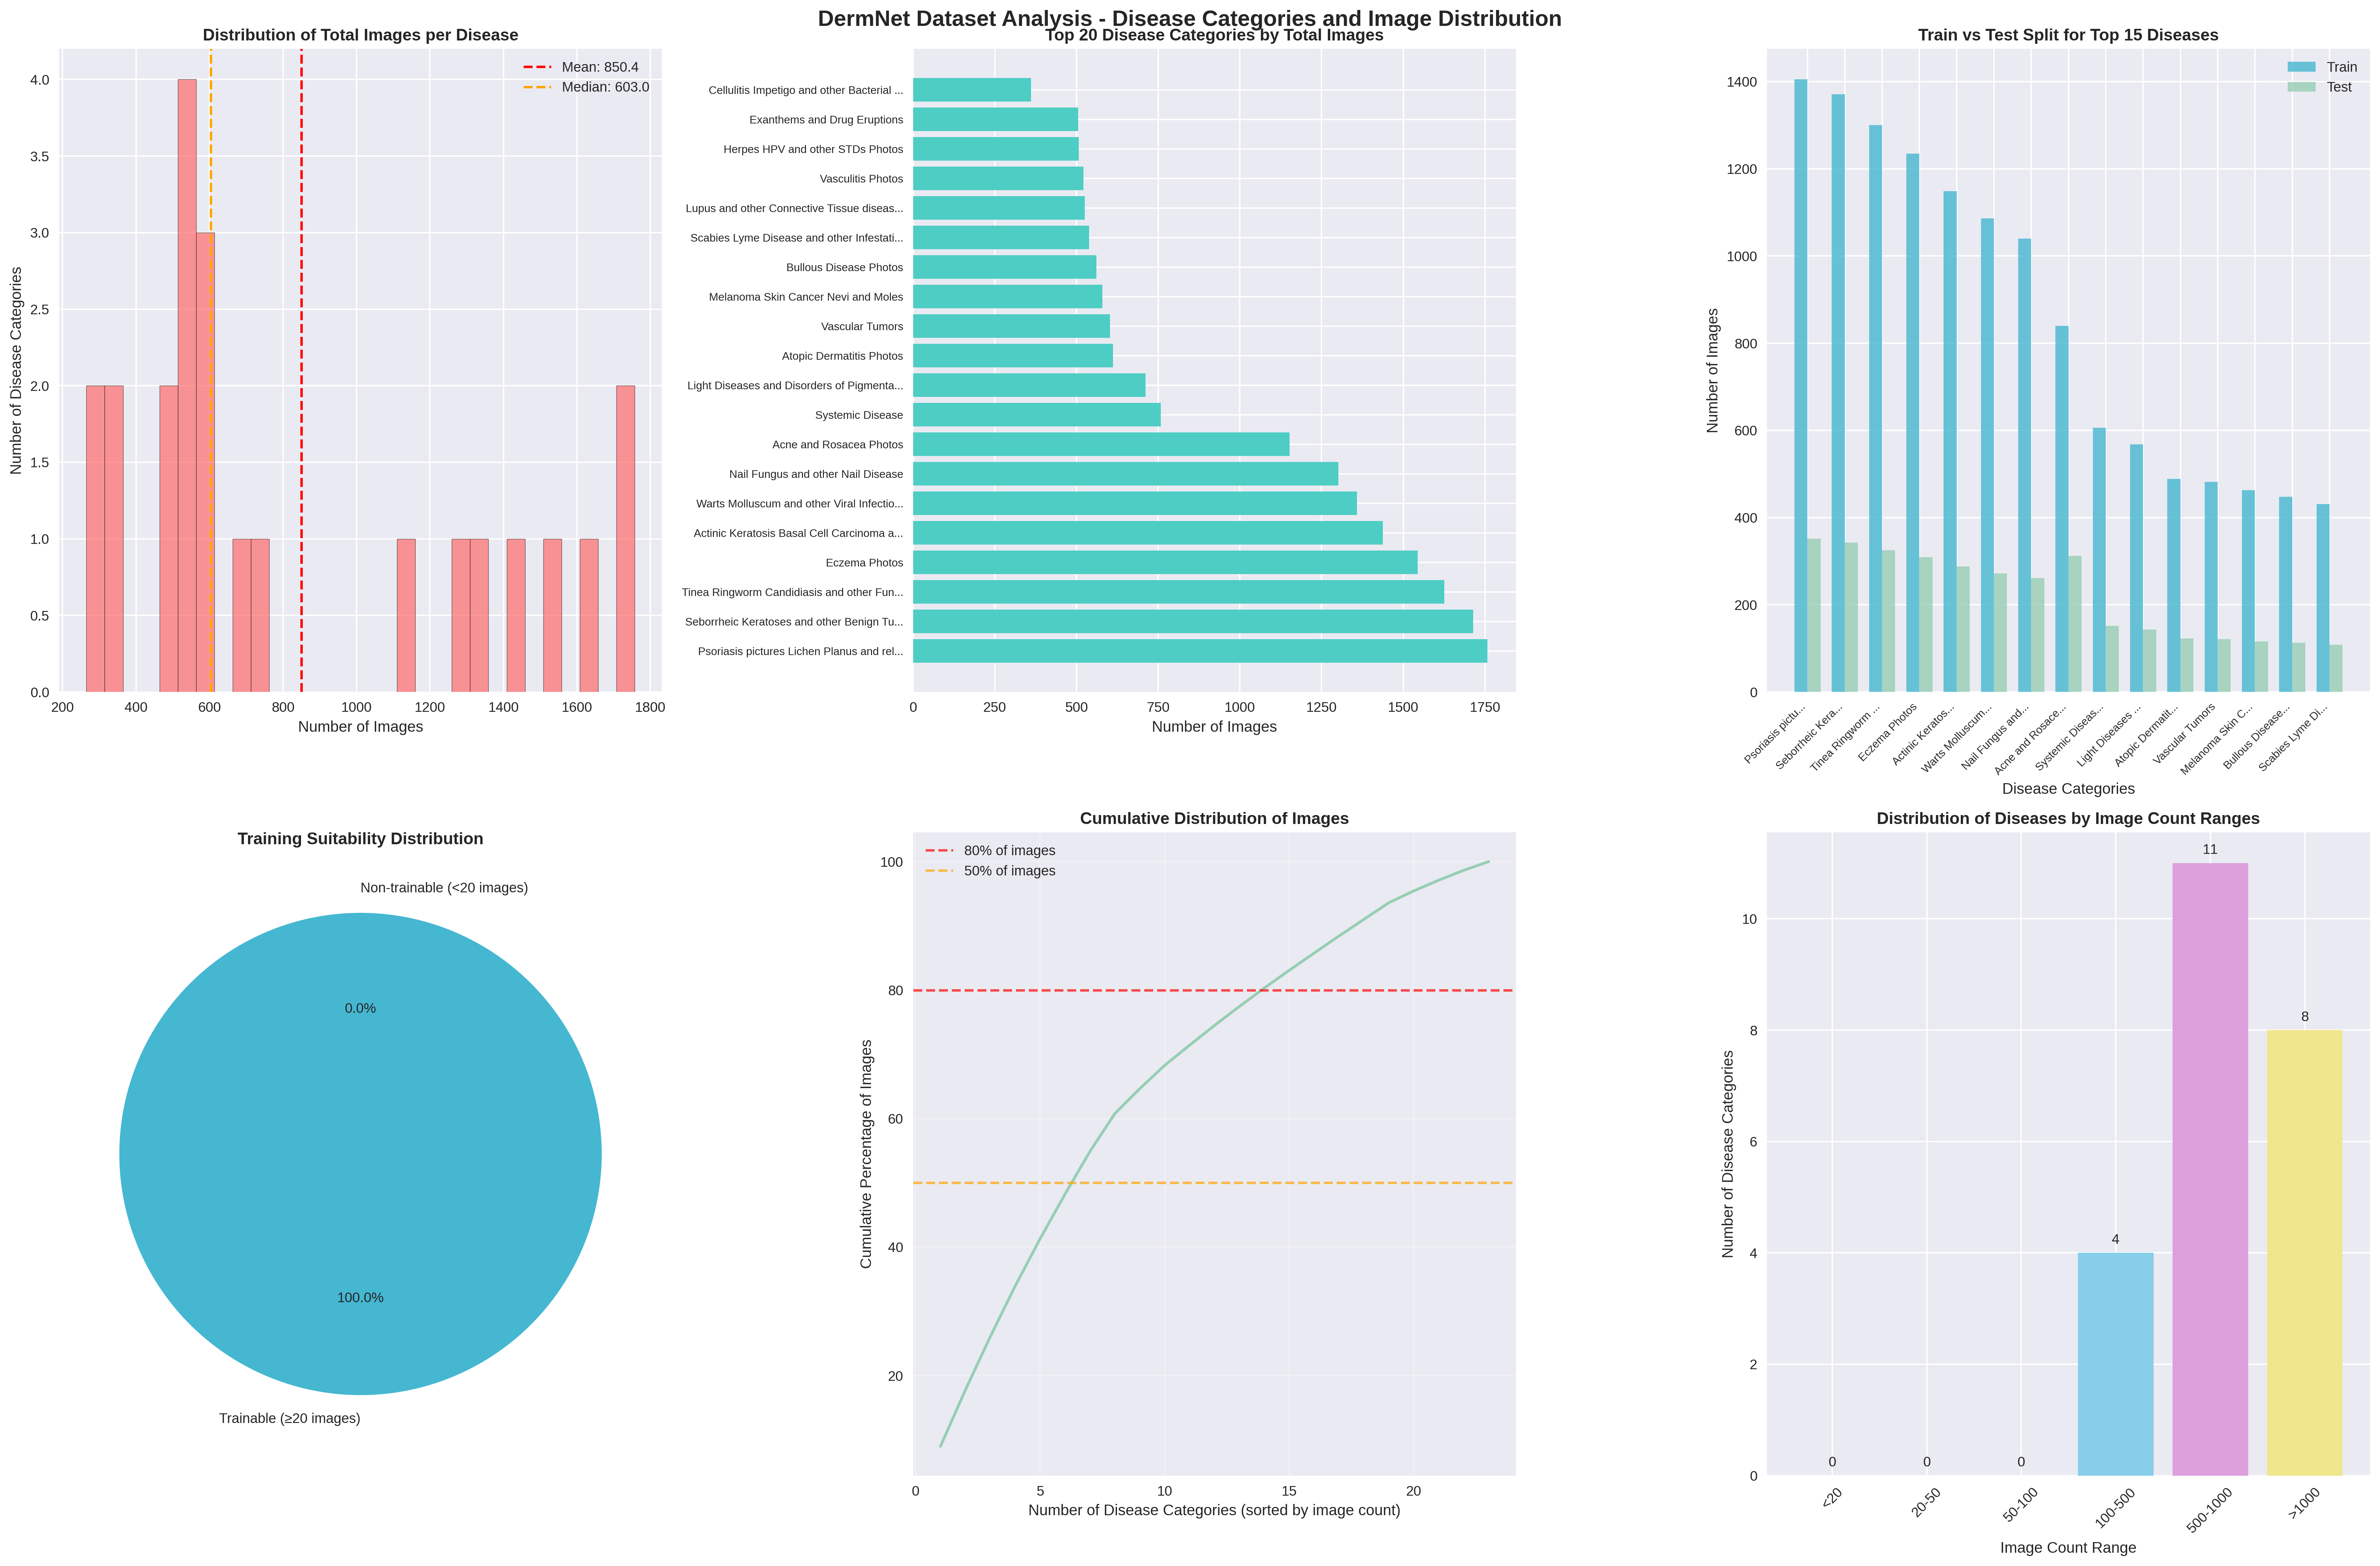

DermNet comprehensive analysis visualization saved as 'dermnet_comprehensive_analysis.png'


In [ ]:
# Create comprehensive visualizations for DermNet dataset
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('DermNet Dataset Analysis - Disease Categories and Image Distribution', fontsize=16, fontweight='bold')

# 1. Distribution of total images per disease
axes[0, 0].hist(dermnet_df['total_images'], bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Total Images per Disease', fontweight='bold')
axes[0, 0].set_xlabel('Number of Images')
axes[0, 0].set_ylabel('Number of Disease Categories')
axes[0, 0].axvline(dermnet_df['total_images'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {dermnet_df["total_images"].mean():.1f}')
axes[0, 0].axvline(dermnet_df['total_images'].median(), color='orange', linestyle='--', 
                   label=f'Median: {dermnet_df["total_images"].median():.1f}')
axes[0, 0].legend()

# 2. Top 20 diseases by total image count
top_20 = dermnet_df.head(20)
axes[0, 1].barh(range(len(top_20)), top_20['total_images'], color='#4ECDC4')
axes[0, 1].set_yticks(range(len(top_20)))
axes[0, 1].set_yticklabels([disease[:40] + '...' if len(disease) > 40 else disease for disease in top_20['disease']], fontsize=8)
axes[0, 1].set_title('Top 20 Disease Categories by Total Images', fontweight='bold')
axes[0, 1].set_xlabel('Number of Images')

# 3. Train vs Test distribution for top 15 diseases
top_15_for_split = dermnet_df.head(15)
x = np.arange(len(top_15_for_split))
width = 0.35

axes[0, 2].bar(x - width/2, top_15_for_split['train_images'], width, label='Train', color='#45B7D1', alpha=0.8)
axes[0, 2].bar(x + width/2, top_15_for_split['test_images'], width, label='Test', color='#96CEB4', alpha=0.8)
axes[0, 2].set_title('Train vs Test Split for Top 15 Diseases', fontweight='bold')
axes[0, 2].set_xlabel('Disease Categories')
axes[0, 2].set_ylabel('Number of Images')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([disease[:15] + '...' if len(disease) > 15 else disease for disease in top_15_for_split['disease']], 
                           rotation=45, ha='right', fontsize=8)
axes[0, 2].legend()

# 4. Training suitability pie chart
trainable_count = len(trainable_diseases)
non_trainable_count = len(dermnet_df) - trainable_count
labels = ['Trainable (≥20 images)', 'Non-trainable (<20 images)']
sizes = [trainable_count, non_trainable_count]
colors = ['#45B7D1', '#FFB6C1']
axes[1, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Training Suitability Distribution', fontweight='bold')

# 5. Cumulative distribution
sorted_counts = np.sort(dermnet_df['total_images'])[::-1]
cumulative_percentage = np.cumsum(sorted_counts) / total_combined_images * 100
axes[1, 1].plot(range(1, len(cumulative_percentage) + 1), cumulative_percentage, 
                color='#96CEB4', linewidth=2)
axes[1, 1].set_title('Cumulative Distribution of Images', fontweight='bold')
axes[1, 1].set_xlabel('Number of Disease Categories (sorted by image count)')
axes[1, 1].set_ylabel('Cumulative Percentage of Images')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of images')
axes[1, 1].axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% of images')
axes[1, 1].legend()

# 6. Image count distribution by ranges
ranges = ['<20', '20-50', '50-100', '100-500', '500-1000', '>1000']
counts = [
    len(dermnet_df[dermnet_df['total_images'] < 20]),
    len(dermnet_df[(dermnet_df['total_images'] >= 20) & (dermnet_df['total_images'] < 50)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 50) & (dermnet_df['total_images'] < 100)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 100) & (dermnet_df['total_images'] < 500)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 500) & (dermnet_df['total_images'] < 1000)]),
    len(dermnet_df[dermnet_df['total_images'] >= 1000])
]

axes[1, 2].bar(ranges, counts, color=['#FFB6C1', '#FFA07A', '#98FB98', '#87CEEB', '#DDA0DD', '#F0E68C'])
axes[1, 2].set_title('Distribution of Diseases by Image Count Ranges', fontweight='bold')
axes[1, 2].set_xlabel('Image Count Range')
axes[1, 2].set_ylabel('Number of Disease Categories')
axes[1, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[1, 2].text(i, v + max(counts)*0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('dermnet_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("DermNet comprehensive analysis visualization saved as 'dermnet_comprehensive_analysis.png'")


In [ ]:
# Additional detailed analysis and summary statistics
print("=" * 80)
print("DERMNET DATASET - DETAILED ANALYSIS SUMMARY")
print("=" * 80)

# Distribution analysis by image count ranges
print(f"\n📈 DISTRIBUTION ANALYSIS BY IMAGE COUNT RANGES:")
print(f"• Diseases with >1000 images: {len(dermnet_df[dermnet_df['total_images'] > 1000])}")
print(f"• Diseases with 500-1000 images: {len(dermnet_df[(dermnet_df['total_images'] >= 500) & (dermnet_df['total_images'] <= 1000)])}")
print(f"• Diseases with 100-500 images: {len(dermnet_df[(dermnet_df['total_images'] >= 100) & (dermnet_df['total_images'] < 500)])}")
print(f"• Diseases with 50-100 images: {len(dermnet_df[(dermnet_df['total_images'] >= 50) & (dermnet_df['total_images'] < 100)])}")
print(f"• Diseases with 20-50 images: {len(dermnet_df[(dermnet_df['total_images'] >= 20) & (dermnet_df['total_images'] < 50)])}")
print(f"• Diseases with <20 images: {len(dermnet_df[dermnet_df['total_images'] < 20])}")

# Train/Test split analysis
print(f"\n🔄 TRAIN/TEST SPLIT ANALYSIS:")
print(f"• Average train/test ratio: {(total_train_images/total_test_images):.2f}:1")
print(f"• Most balanced disease: {dermnet_df.loc[dermnet_df['train_images'].div(dermnet_df['test_images']).abs().idxmin(), 'disease']}")
print(f"• Most imbalanced disease: {dermnet_df.loc[dermnet_df['train_images'].div(dermnet_df['test_images']).abs().idxmax(), 'disease']}")

# Top performers analysis
print(f"\n🏆 TOP PERFORMERS:")
print(f"• Most common disease: {dermnet_df.iloc[0]['disease']} ({dermnet_df.iloc[0]['total_images']} images)")
print(f"• Second most common: {dermnet_df.iloc[1]['disease']} ({dermnet_df.iloc[1]['total_images']} images)")
print(f"• Third most common: {dermnet_df.iloc[2]['disease']} ({dermnet_df.iloc[2]['total_images']} images)")

# Rare diseases analysis
print(f"\n📉 RARE DISEASES:")
print(f"• Least common disease: {dermnet_df.iloc[-1]['disease']} ({dermnet_df.iloc[-1]['total_images']} images)")
print(f"• Second least common: {dermnet_df.iloc[-2]['disease']} ({dermnet_df.iloc[-2]['total_images']} images)")
print(f"• Third least common: {dermnet_df.iloc[-3]['disease']} ({dermnet_df.iloc[-3]['total_images']} images)")

# Dataset quality metrics
print(f"\n📊 DATASET QUALITY METRICS:")
print(f"• Total diseases: {total_disease_categories}")
print(f"• Total images: {total_combined_images:,}")
print(f"• Images per disease (avg): {total_combined_images/total_disease_categories:.1f}")
print(f"• Images per disease (median): {dermnet_df['total_images'].median():.1f}")
print(f"• Standard deviation: {dermnet_df['total_images'].std():.1f}")
print(f"• Coefficient of variation: {(dermnet_df['total_images'].std()/dermnet_df['total_images'].mean())*100:.1f}%")

# Training recommendations
print(f"\n💡 TRAINING RECOMMENDATIONS:")
print(f"• Diseases suitable for training (≥20 images): {len(trainable_diseases)}/{total_disease_categories} ({len(trainable_diseases)/total_disease_categories*100:.1f}%)")
print(f"• Diseases suitable for validation (≥50 images): {len(dermnet_df[dermnet_df['total_images'] >= 50])}/{total_disease_categories}")
print(f"• Diseases suitable for testing (≥100 images): {len(dermnet_df[dermnet_df['total_images'] >= 100])}/{total_disease_categories}")
print(f"• Recommended minimum samples per class: 20")
print(f"• Recommended optimal samples per class: 100+")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


DERMNET DATASET - DETAILED ANALYSIS SUMMARY

📈 DISTRIBUTION ANALYSIS BY IMAGE COUNT RANGES:
• Diseases with >1000 images: 8
• Diseases with 500-1000 images: 11
• Diseases with 100-500 images: 4
• Diseases with 50-100 images: 0
• Diseases with 20-50 images: 0
• Diseases with <20 images: 0

🔄 TRAIN/TEST SPLIT ANALYSIS:
• Average train/test ratio: 3.89:1
• Most balanced disease: Acne and Rosacea Photos
• Most imbalanced disease: Tinea Ringworm Candidiasis and other Fungal Infections

🏆 TOP PERFORMERS:
• Most common disease: Psoriasis pictures Lichen Planus and related diseases (1757 images)
• Second most common: Seborrheic Keratoses and other Benign Tumors (1714 images)
• Third most common: Tinea Ringworm Candidiasis and other Fungal Infections (1625 images)

📉 RARE DISEASES:
• Least common disease: Urticaria Hives (265 images)
• Second least common: Hair Loss Photos Alopecia and other Hair Diseases (299 images)
• Third least common: Poison Ivy Photos and other Contact Dermatitis (325 ima